### Student Performance Prediction Using ANN

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import StandardScaler, LabelEncoder
from sklearn.metrics          import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow                import keras
from tensorflow.keras          import Sequential
from tensorflow.keras.layers   import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)
tf.random.set_seed(42)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 11



In [2]:
df = pd.read_csv(r'G:\Jupyter Notebook\Practice Data Files\student_performance_prediction_dataset-2.csv')


In [3]:
df.shape

(300000, 25)

In [4]:
df.head()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
0,1,21,Male,1.645404,79.154521,8.230886,96.053840,7.719620,1.871170,1.447894,...,4.018412,Medium,Master,Yes,Mobile,Private,Coding Club,59.248749,D,Pass
1,2,18,Male,4.462126,72.526685,6.139219,53.024821,6.754758,5.630071,1.891288,...,3.268642,Medium,Master,Yes,Laptop,Public,NaN,58.595595,D,Pass
2,3,19,Female,6.220212,98.531716,6.946313,78.775422,10.000000,7.862877,1.774356,...,2.327293,Low,High School,Yes,Tablet,Private,Music,85.855289,A,Pass
3,4,21,Female,1.826644,97.731245,8.297048,76.122618,7.440486,2.316252,1.204271,...,1.163367,Medium,Bachelor,Yes,Laptop,Public,Debate,42.117503,F,Fail
4,5,17,Male,3.789322,78.589107,6.777171,81.305681,9.962609,5.335697,1.399230,...,0.411183,High,High School,Yes,Laptop,Private,Debate,62.870474,C,Pass


In [5]:
df.tail()

,student_id,age,gender,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,...,social_media_hours,family_income,parent_education,internet_access,device_type,school_type,extracurriculars,final_grade,grade_category,pass_fail
299995,299996,20,Female,4.997969,74.093222,7.440359,52.347483,7.919553,6.528064,1.362207,...,4.708792,Medium,PhD,Yes,Mobile,Private,Arts,48.932617,F,Fail
299996,299997,17,Female,4.046644,90.982332,8.604581,83.542563,7.634545,4.677627,1.657900,...,2.797866,High,High School,Yes,Mobile,Public,Music,54.907427,D,Pass
299997,299998,16,Male,3.270361,62.681191,7.630534,72.803779,8.405001,2.453354,0.505174,...,3.264763,Medium,High School,Yes,Laptop,Public,Sports,30.199483,F,Fail
299998,299999,17,Female,1.907116,95.109287,6.341972,63.691808,9.025269,7.843200,0.000000,...,3.611083,Medium,Bachelor,Yes,NaN,Public,Music,65.075466,C,Pass
299999,300000,20,Male,0.498701,95.549121,4.670566,46.527411,5.306086,2.419068,3.301766,...,2.240141,Medium,Master,No,Tablet,Private,Sports,31.733528,F,Fail


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 25 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   student_id             300000 non-null  int64  
 1   age                    300000 non-null  int64  
 2   gender                 300000 non-null  object 
 3   study_hours            300000 non-null  float64
 4   attendance             300000 non-null  float64
 5   sleep_hours            300000 non-null  float64
 6   previous_grade         300000 non-null  float64
 7   assignments_completed  300000 non-null  float64
 8   practice_tests_taken   300000 non-null  float64
 9   group_study_hours      300000 non-null  float64
 10  notes_quality_score    300000 non-null  float64
 11  time_management_score  300000 non-null  float64
 12  motivation_level       300000 non-null  float64
 13  mental_health_score    300000 non-null  float64
 14  screen_time            300000 non-nu

In [8]:
df.describe()

,student_id,age,study_hours,attendance,sleep_hours,previous_grade,assignments_completed,practice_tests_taken,group_study_hours,notes_quality_score,time_management_score,motivation_level,mental_health_score,screen_time,social_media_hours,final_grade
count,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000,300000.000000
mean,150000.500000,17.999070,4.503062,84.699395,6.991431,69.840184,7.836044,4.017508,1.529057,6.946017,6.464472,6.945851,6.984210,4.018094,2.530258,53.089206
std,86602.684716,1.999235,1.978513,9.419450,1.463070,14.683157,1.732474,1.956444,0.941525,1.885193,1.925801,1.886246,1.471193,1.958596,1.435742,12.225161
min,1.000000,15.000000,0.000000,40.000000,3.000000,20.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,75000.750000,16.000000,3.143566,78.241008,5.992666,59.870863,6.654817,2.655243,0.826462,5.653740,5.138654,5.655885,5.982593,2.650836,1.491633,44.867737
50%,150000.500000,18.000000,4.498272,84.990371,6.999011,69.955736,8.000829,4.001981,1.499206,7.011212,6.493222,7.005390,6.992543,3.997134,2.498493,53.167495
75%,225000.250000,20.000000,5.843646,91.732244,8.013284,80.102857,9.357154,5.349494,2.172680,8.356150,7.845919,8.356416,8.010331,5.350158,3.513496,61.379373
max,300000.000000,21.000000,12.000000,100.000000,10.000000,100.000000,10.000000,10.000000,5.840593,10.000000,10.000000,10.000000,10.000000,12.000000,8.000000,100.000000


In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
student_id,300000.0,150000.500000,86602.684716,1.0,75000.750000,150000.500000,225000.250000,300000.000000
age,300000.0,17.999070,1.999235,15.0,16.000000,18.000000,20.000000,21.000000
study_hours,300000.0,4.503062,1.978513,0.0,3.143566,4.498272,5.843646,12.000000
attendance,300000.0,84.699395,9.419450,40.0,78.241008,84.990371,91.732244,100.000000
sleep_hours,300000.0,6.991431,1.463070,3.0,5.992666,6.999011,8.013284,10.000000
previous_grade,300000.0,69.840184,14.683157,20.0,59.870863,69.955736,80.102857,100.000000
assignments_completed,300000.0,7.836044,1.732474,0.0,6.654817,8.000829,9.357154,10.000000
practice_tests_taken,300000.0,4.017508,1.956444,0.0,2.655243,4.001981,5.349494,10.000000
group_study_hours,300000.0,1.529057,0.941525,0.0,0.826462,1.499206,2.172680,5.840593
notes_quality_score,300000.0,6.946017,1.885193,1.0,5.653740,7.011212,8.356150,10.000000


In [17]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
study_hours                  0
attendance                   0
sleep_hours                  0
previous_grade               0
assignments_completed        0
practice_tests_taken         0
group_study_hours            0
notes_quality_score          0
time_management_score        0
motivation_level             0
mental_health_score          0
screen_time                  0
social_media_hours           0
family_income                0
parent_education             0
internet_access              0
device_type              15105
school_type                  0
extracurriculars         49981
final_grade                  0
grade_category               4
pass_fail                    0
dtype: int64

In [18]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %':     missing_pct
})



In [19]:
dup_count = df.duplicated().sum()
print('Total duplicate rows:', dup_count)
if dup_count == 0:
    print('No duplicates found!')

Total duplicate rows: 0
No duplicates found!


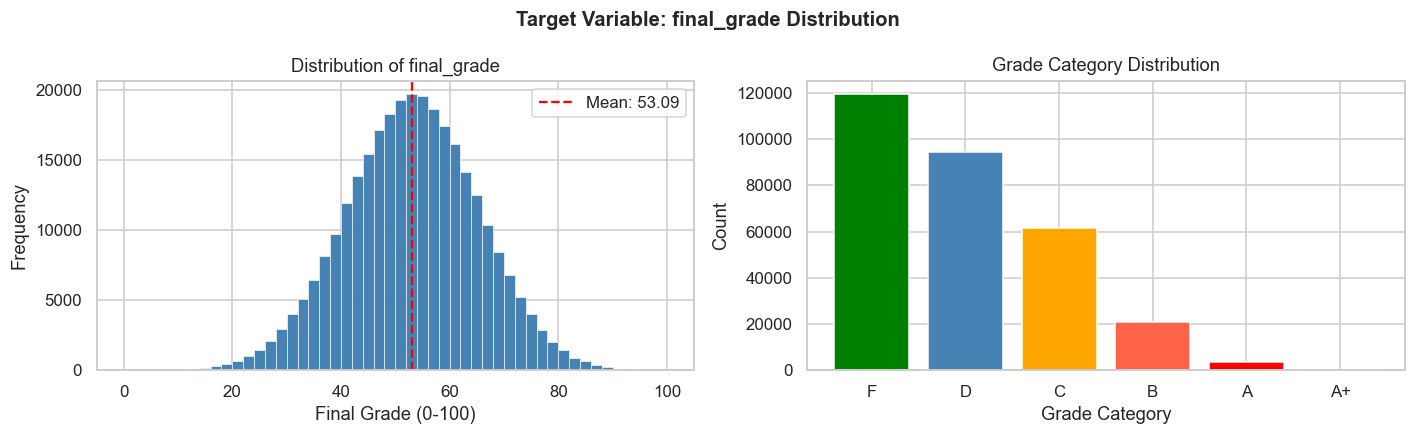

Final Grade Statistics:
count    300000.00
mean         53.09
std          12.23
min           0.00
25%          44.87
50%          53.17
75%          61.38
max         100.00


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Target Variable: final_grade Distribution', fontweight='bold')

axes[0].hist(df['final_grade'], bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].axvline(df['final_grade'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["final_grade"].mean():.2f}')
axes[0].set_title('Distribution of final_grade')
axes[0].set_xlabel('Final Grade (0-100)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

grade_counts = df['grade_category'].value_counts()
axes[1].bar(grade_counts.index, grade_counts.values,
            color=['green','steelblue','orange','tomato','red','darkred'],
            edgecolor='white')
axes[1].set_title('Grade Category Distribution')
axes[1].set_xlabel('Grade Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print('Final Grade Statistics:')
print(df['final_grade'].describe().round(2).to_string())

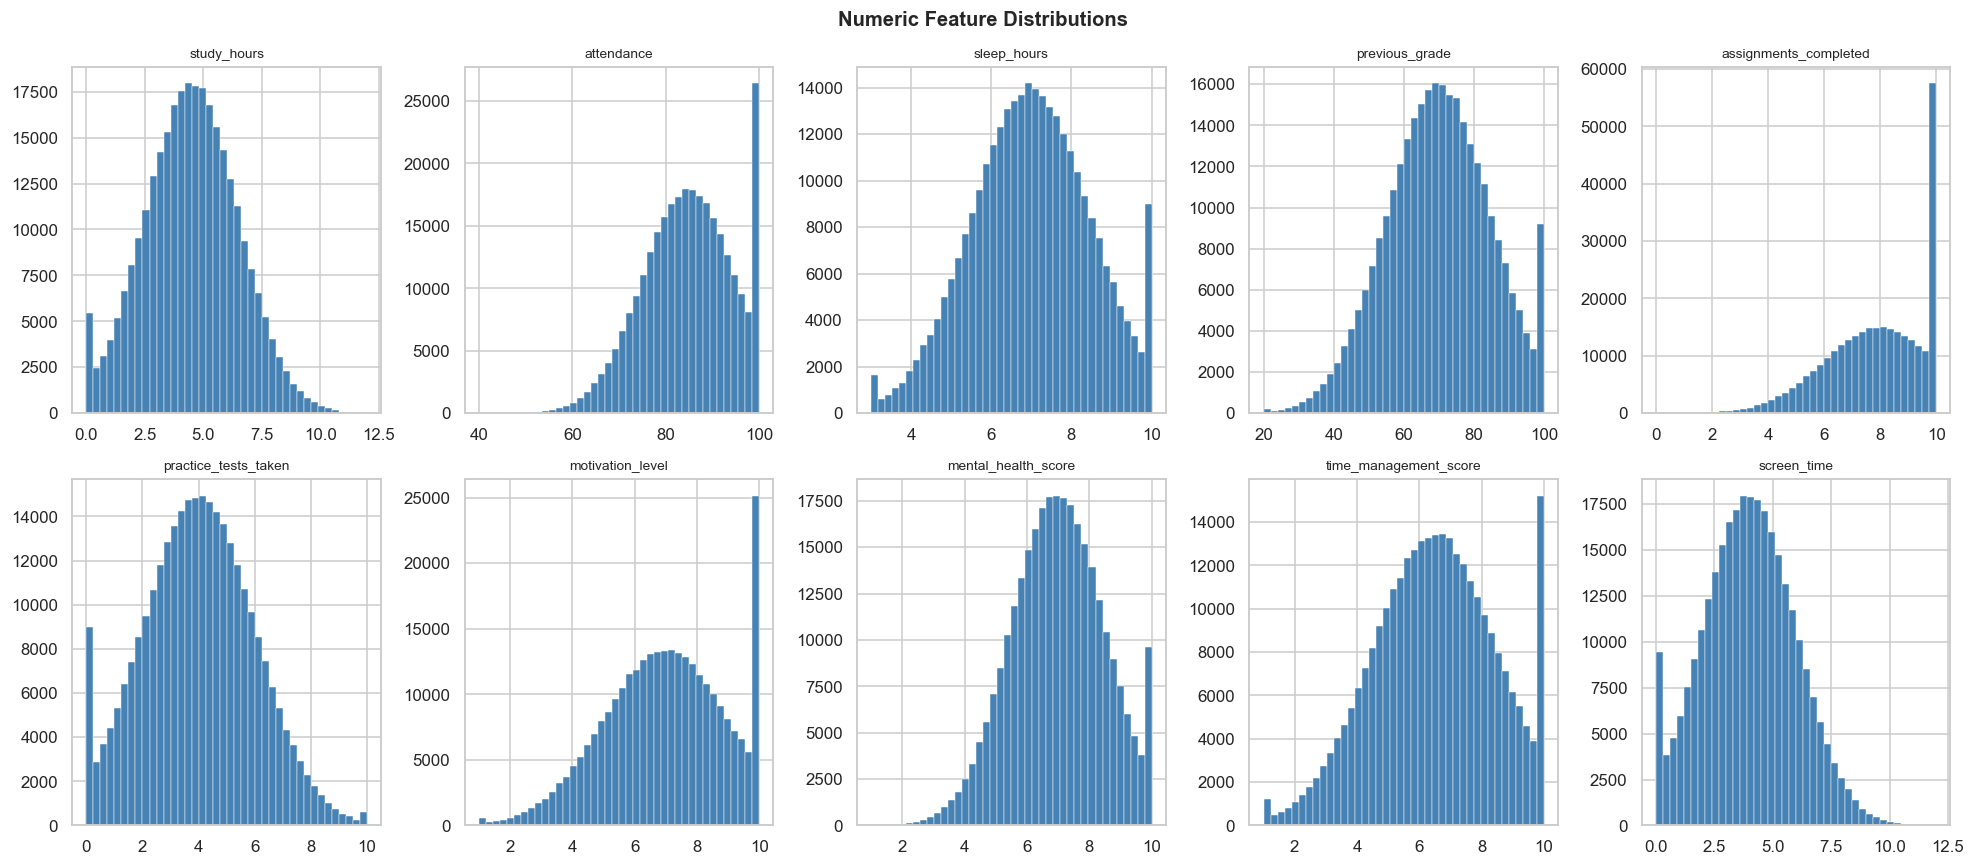

In [21]:
numeric_cols = ['study_hours','attendance','sleep_hours','previous_grade',
                'assignments_completed','practice_tests_taken','motivation_level',
                'mental_health_score','time_management_score','screen_time']

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Numeric Feature Distributions', fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes_flat[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes_flat[i].set_title(col, fontsize=9)
    axes_flat[i].set_xlabel('')

plt.tight_layout()
plt.show()

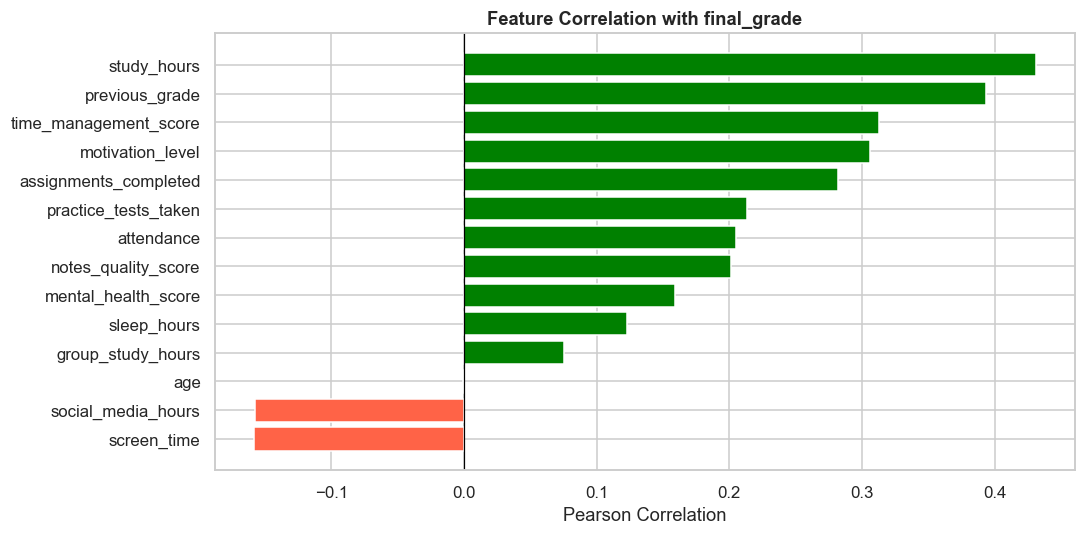

Top 5 positive correlations:
study_hours              0.431
previous_grade           0.393
time_management_score    0.313
motivation_level         0.306
assignments_completed    0.282

Top 5 negative correlations:
sleep_hours           0.123
group_study_hours     0.076
age                  -0.001
social_media_hours   -0.157
screen_time          -0.158


In [22]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['student_id'])
corr   = num_df.corr()['final_grade'].drop('final_grade').sort_values(ascending=False)

plt.figure(figsize=(10, 5))
colors = ['green' if v > 0 else 'tomato' for v in corr.values]
plt.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with final_grade', fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()

print('Top 5 positive correlations:')
print(corr.head(5).round(3).to_string())
print('\nTop 5 negative correlations:')
print(corr.tail(5).round(3).to_string())

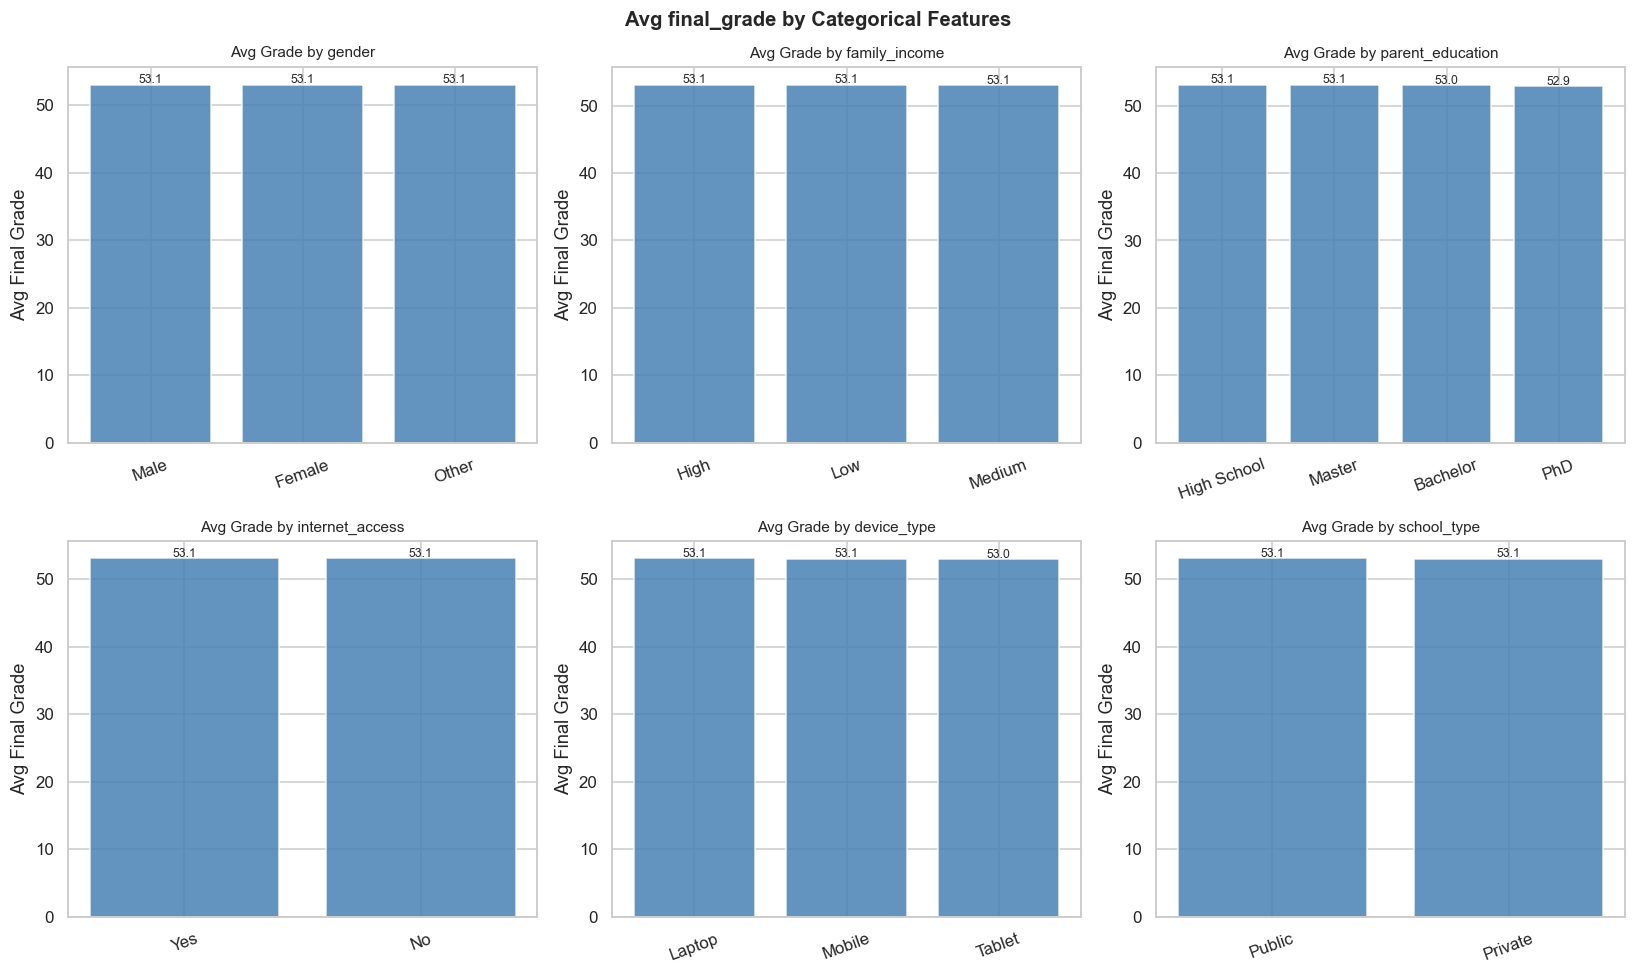

In [23]:
cat_cols = ['gender','family_income','parent_education','internet_access',
            'device_type','school_type']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Avg final_grade by Categorical Features', fontweight='bold')
axes_flat = axes.flatten()

for i, col in enumerate(cat_cols):
    avg = df.groupby(col)['final_grade'].mean().sort_values(ascending=False)
    axes_flat[i].bar(avg.index.astype(str), avg.values,
                     color='steelblue', edgecolor='white', alpha=0.85)
    axes_flat[i].set_title(f'Avg Grade by {col}', fontsize=10)
    axes_flat[i].set_ylabel('Avg Final Grade')
    axes_flat[i].tick_params(axis='x', rotation=20)
    for j, v in enumerate(avg.values):
        axes_flat[i].text(j, v + 0.2, f'{v:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
# student_id: just a row number, no predictive value
# grade_category: derived directly from final_grade (leakage)
# pass_fail: derived directly from final_grade (leakage)

df = df.drop(columns=['student_id', 'grade_category', 'pass_fail'])

print('Dropped: student_id, grade_category, pass_fail')
print('New shape:', df.shape)

Dropped: student_id, grade_category, pass_fail
New shape: (300000, 22)


In [25]:
device_mode = df['device_type'].mode()[0]
df['device_type'] = df['device_type'].fillna(device_mode)
print(f'\ndevice_type filled with mode: "{device_mode}"')

df['extracurriculars'] = df['extracurriculars'].fillna('None')
print('extracurriculars filled with: "None"')



device_type filled with mode: "Laptop"
extracurriculars filled with: "None"


In [26]:
le = LabelEncoder()

label_cols = ['gender', 'internet_access', 'school_type']
for col in label_cols:
    df[col] = le.fit_transform(df[col])
    print(f'Label Encoded: {col}')

ohe_cols = ['family_income', 'parent_education', 'device_type', 'extracurriculars']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)
print(f'One-Hot Encoded: {ohe_cols}')

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)


Label Encoded: gender
Label Encoded: internet_access
Label Encoded: school_type
One-Hot Encoded: ['family_income', 'parent_education', 'device_type', 'extracurriculars']


In [27]:
X = df.drop(columns=['final_grade'])
y = df['final_grade']


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [29]:
scaler = StandardScaler()

X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('StandardScaler applied!')
print('X_train_sc shape:', X_train_sc.shape)
print('X_test_sc  shape:', X_test_sc.shape)

n_features = X_train_sc.shape[1]
print(f'\nNumber of input features: {n_features}')

StandardScaler applied!
X_train_sc shape: (240000, 29)
X_test_sc  shape: (60000, 29)

Number of input features: 29


In [30]:
def evaluate_model(model, X_te, y_te, name='Model'):
    y_pred = model.predict(X_te, verbose=0).flatten()
    mae    = mean_absolute_error(y_te, y_pred)
    mse    = mean_squared_error(y_te,  y_pred)
    rmse   = np.sqrt(mse)
    r2     = r2_score(y_te, y_pred)
    return y_pred, mae, rmse, r2

def plot_history(history, title='Training History'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontweight='bold')

    axes[0].plot(history.history['loss'],     color='steelblue', label='Train Loss')
    axes[0].plot(history.history['val_loss'], color='tomato',    label='Val Loss', linestyle='--')
    axes[0].set_title('Loss (MSE)')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    axes[1].plot(history.history['mae'],     color='steelblue', label='Train MAE')
    axes[1].plot(history.history['val_mae'], color='tomato',    label='Val MAE', linestyle='--')
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

all_results = []
all_histories = {}
all_predictions = {}

early_stop = EarlyStopping(
    monitor='val_loss', patience=8,
    restore_best_weights=True, verbose=0
)


In [31]:
model1 = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dense(1)
])

model1.compile(
    optimizer = 'adam',
    loss      = 'mse',
    metrics   = ['mae']
)

print('Model 1 Summary:')
model1.summary()

history1 = model1.fit(
    X_train_sc, y_train,
    epochs          = 50,
    batch_size      = 512,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 1'] = history1
y_pred1, mae1, rmse1, r2_1 = evaluate_model(model1, X_test_sc, y_test)
all_predictions['Model 1'] = y_pred1

print(f'\nModel 1 Results:')
print(f'  MAE  : {mae1:.4f}')
print(f'  RMSE : {rmse1:.4f}')
print(f'  R2   : {r2_1:.4f}')

all_results.append({
    'Model': 'Model 1', 'Activation': 'ReLU', 'Optimizer': 'Adam',
    'Epochs': len(history1.history['loss']), 'Layers': '256-128-64',
    'Batch': 512,
    'MAE': round(mae1,4), 'RMSE': round(rmse1,4), 'R2': round(r2_1,4)
})

Model 1 Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │           7,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 49,921 (195.00 KB)

 Trainable params: 49,409 (193.00 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 225.2497 - mae: 9.6044 - val_loss: 89.7088 - val_mae: 8.1509
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 54.1461 - mae: 5.8615 - val_loss: 37.9617 - val_mae: 4.9564
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 49.6049 - mae: 5.6049 - val_loss: 37.2573 - val_mae: 4.9153
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 47.0143 - mae: 5.4598 - val_loss: 37.6429 - val_mae: 4.9444
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 44.7671 - mae: 5.3242 - val_loss: 38.2766 - val_mae: 4.9927
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 43.1374 - mae: 5.2360 - val_loss: 37.3941 - val_mae: 4.9300
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 41.6580 - mae: 5.1407 - val_loss: 37.7873 - val_mae: 4.9572
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 40.3263 - mae: 5.0592 - val_loss: 34.4104 - val_mae: 4.7073
Epoch 9/50
399/399 ━━━━━━━━━━━

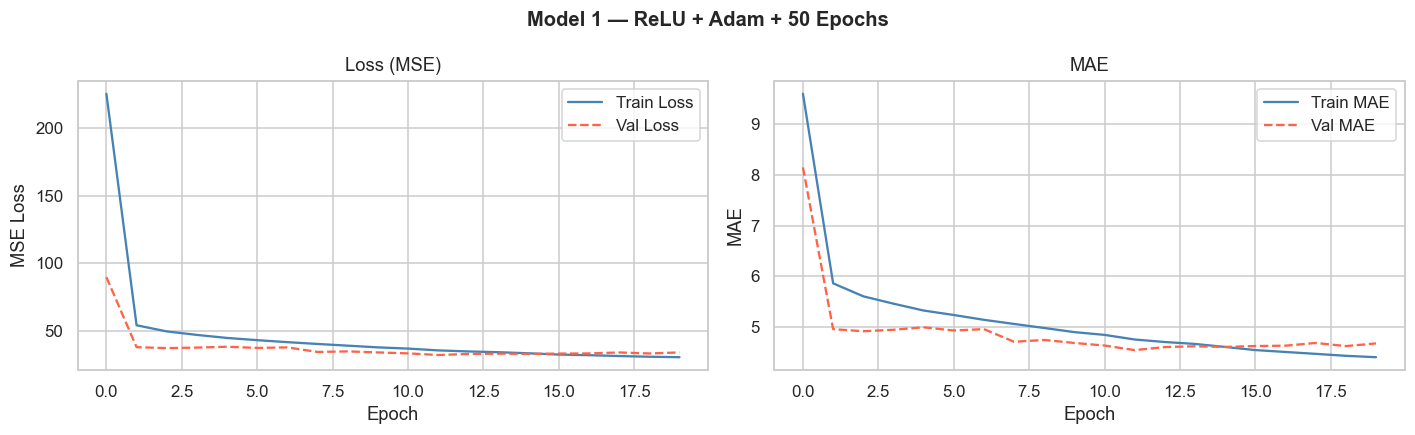

In [32]:
plot_history(history1, 'Model 1 — ReLU + Adam + 50 Epochs')

In [33]:
model2 = Sequential([
    Dense(128, activation='tanh', input_shape=(n_features,)),
    BatchNormalization(),
    Dense(64,  activation='tanh'),
    Dropout(0.2),
    Dense(32,  activation='tanh'),
    Dense(1)
])

model2.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss      = 'mse',
    metrics   = ['mae']
)

history2 = model2.fit(
    X_train_sc, y_train,
    epochs          = 50,
    batch_size      = 512,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 2'] = history2
y_pred2, mae2, rmse2, r2_2 = evaluate_model(model2, X_test_sc, y_test)
all_predictions['Model 2'] = y_pred2

print(f'\nModel 2 Results:')
print(f'  MAE  : {mae2:.4f}')
print(f'  RMSE : {rmse2:.4f}')
print(f'  R2   : {r2_2:.4f}')

all_results.append({
    'Model': 'Model 2', 'Activation': 'Tanh', 'Optimizer': 'SGD',
    'Epochs': len(history2.history['loss']), 'Layers': '128-64-32',
    'Batch': 512,
    'MAE': round(mae2,4), 'RMSE': round(rmse2,4), 'R2': round(r2_2,4)
})

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 184.2004 - mae: 10.5055 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 150.8885 - mae: 9.8046 - val_loss: 149.6623 - val_mae: 9.7520
Epoch 9/50
399/399 ━━━━

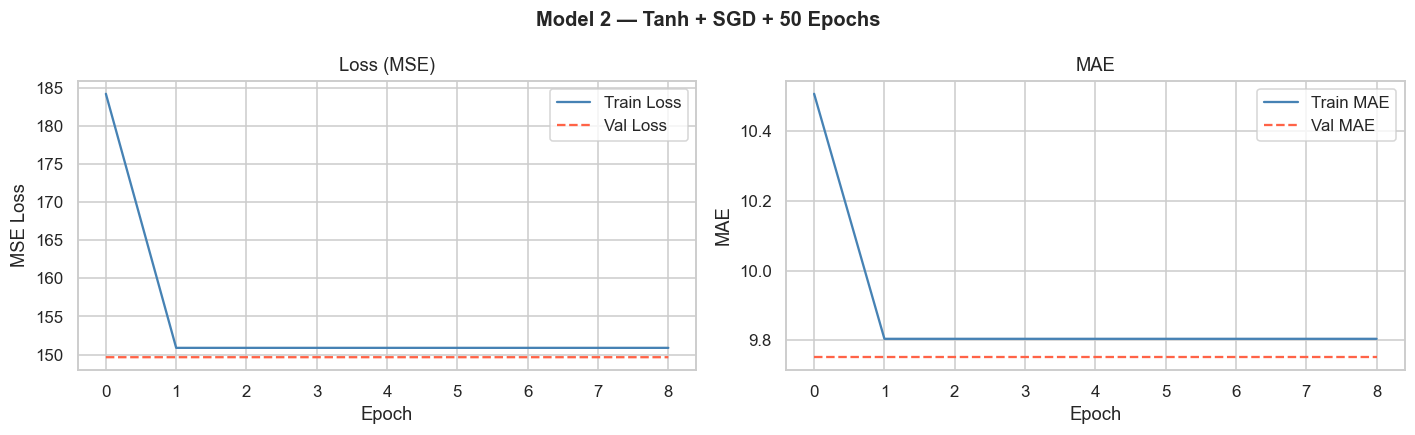

In [34]:
plot_history(history2, 'Model 2 — Tanh + SGD + 50 Epochs')

In [35]:
model3 = Sequential([
    Dense(512, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dense(1)
])

model3.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

history3 = model3.fit(
    X_train_sc, y_train,
    epochs          = 100,
    batch_size      = 1024,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 3'] = history3
y_pred3, mae3, rmse3, r2_3 = evaluate_model(model3, X_test_sc, y_test)
all_predictions['Model 3'] = y_pred3

print(f'\nModel 3 Results:')
print(f'  MAE  : {mae3:.4f}')
print(f'  RMSE : {rmse3:.4f}')
print(f'  R2   : {r2_3:.4f}')

all_results.append({
    'Model': 'Model 3', 'Activation': 'ReLU', 'Optimizer': 'RMSprop',
    'Epochs': len(history3.history['loss']), 'Layers': '512-256-128-64',
    'Batch': 1024,
    'MAE': round(mae3,4), 'RMSE': round(rmse3,4), 'R2': round(r2_3,4)
})

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - loss: 180.9188 - mae: 8.8002 - val_loss: 92.9550 - val_mae: 7.7478
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 50.6658 - mae: 5.6663 - val_loss: 30.7473 - val_mae: 4.4297
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 47.2365 - mae: 5.4750 - val_loss: 37.5151 - val_mae: 4.9155
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 45.4345 - mae: 5.3698 - val_loss: 31.4381 - val_mae: 4.4896
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - loss: 43.9772 - mae: 5.2838 - val_loss: 35.4789 - val_mae: 4.7839
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - loss: 42.8841 - mae: 5.2196 - val_loss: 34.4599 - val_mae: 4.7157
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 41.9662 - mae: 5.1621 - val_loss: 37.9159 - val_mae: 4.9636
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - loss: 41.4497 - mae: 5.1268 - val_loss: 33.1903 - val_mae: 4.6167
Epoch 9/100
200/200 ━

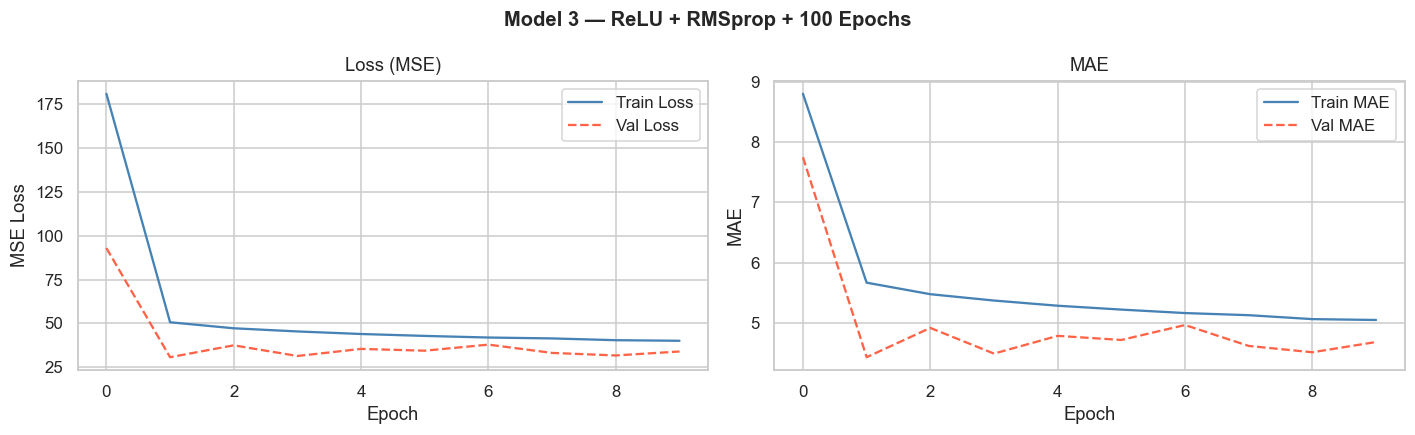

In [36]:
plot_history(history3, 'Model 3 — ReLU + RMSprop + 100 Epochs')

In [37]:
model4 = Sequential([
    Dense(128, activation='sigmoid', input_shape=(n_features,)),
    Dropout(0.2),
    Dense(64,  activation='sigmoid'),
    Dense(1)
])

model4.compile(
    optimizer = 'adam',
    loss      = 'mse',
    metrics   = ['mae']
)

early_stop_20 = EarlyStopping(monitor='val_loss', patience=5,
                              restore_best_weights=True, verbose=0)

history4 = model4.fit(
    X_train_sc, y_train,
    epochs          = 20,
    batch_size      = 512,
    validation_split= 0.15,
    callbacks       = [early_stop_20],
    verbose         = 1
)

all_histories['Model 4'] = history4
y_pred4, mae4, rmse4, r2_4 = evaluate_model(model4, X_test_sc, y_test)
all_predictions['Model 4'] = y_pred4

print(f'\nModel 4 Results:')
print(f'  MAE  : {mae4:.4f}')
print(f'  RMSE : {rmse4:.4f}')
print(f'  R2   : {r2_4:.4f}')

all_results.append({
    'Model': 'Model 4', 'Activation': 'Sigmoid', 'Optimizer': 'Adam',
    'Epochs': len(history4.history['loss']), 'Layers': '128-64',
    'Batch': 512,
    'MAE': round(mae4,4), 'RMSE': round(rmse4,4), 'R2': round(r2_4,4)
})

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 1782.6074 - mae: 40.0732 - val_loss: 1144.8829 - val_mae: 31.6044
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 781.8555 - mae: 25.1102 - val_loss: 480.0493 - val_mae: 18.9531
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 333.1742 - mae: 15.1468 - val_loss: 216.6936 - val_mae: 11.6902
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 151.6961 - mae: 9.3876 - val_loss: 105.4089 - val_mae: 7.6615
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 84.8263 - mae: 6.8486 - val_loss: 67.3701 - val_mae: 6.0991
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 58.2430 - mae: 5.6945 - val_loss: 49.6991 - val_mae: 5.2839
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 45.3409 - mae: 5.0868 - val_loss: 40.3666 - val_mae: 4.8228
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 38.2030 - mae: 4.7317 - val_loss: 35.0427 - val_mae: 4.5452
Epoch 9/20
399/399 ━━━━━

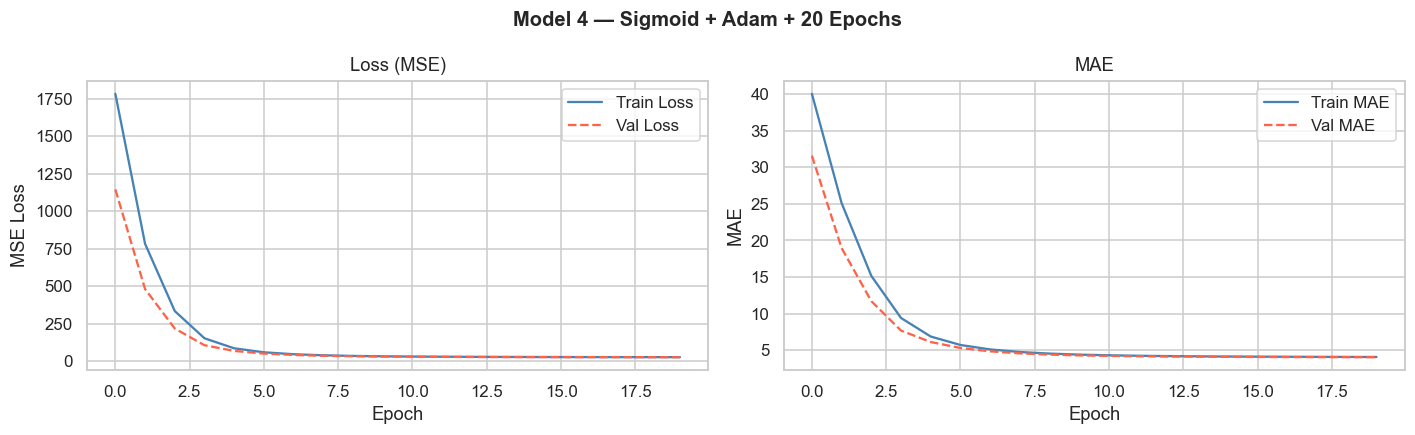

In [38]:
plot_history(history4, 'Model 4 — Sigmoid + Adam + 20 Epochs')

In [39]:
model5 = Sequential([
    Dense(512, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.25),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dropout(0.1),
    Dense(32,  activation='relu'),
    Dense(1)
])

model5.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

history5 = model5.fit(
    X_train_sc, y_train,
    epochs          = 100,
    batch_size      = 1024,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 5'] = history5
y_pred5, mae5, rmse5, r2_5 = evaluate_model(model5, X_test_sc, y_test)
all_predictions['Model 5'] = y_pred5

print(f'\nModel 5 Results:')
print(f'  MAE  : {mae5:.4f}')
print(f'  RMSE : {rmse5:.4f}')
print(f'  R2   : {r2_5:.4f}')

all_results.append({
    'Model': 'Model 5', 'Activation': 'ReLU', 'Optimizer': 'Adam',
    'Epochs': len(history5.history['loss']), 'Layers': '512-256-128-64-32',
    'Batch': 1024,
    'MAE': round(mae5,4), 'RMSE': round(rmse5,4), 'R2': round(r2_5,4)
})

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - loss: 388.9897 - mae: 12.9196 - val_loss: 60.6237 - val_mae: 6.1680
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - loss: 61.6598 - mae: 6.2522 - val_loss: 41.4028 - val_mae: 5.1802
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 54.0906 - mae: 5.8580 - val_loss: 39.4467 - val_mae: 5.0763
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 49.9001 - mae: 5.6256 - val_loss: 49.7368 - val_mae: 5.7956
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 47.3929 - mae: 5.4798 - val_loss: 50.4819 - val_mae: 5.8531
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - loss: 45.4257 - mae: 5.3603 - val_loss: 62.7947 - val_mae: 6.6575
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - loss: 43.4685 - mae: 5.2547 - val_loss: 72.3512 - val_mae: 7.2472
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - loss: 42.2766 - mae: 5.1749 - val_loss: 84.3840 - val_mae: 7.9397
Epoch 9/100
200/200 ━

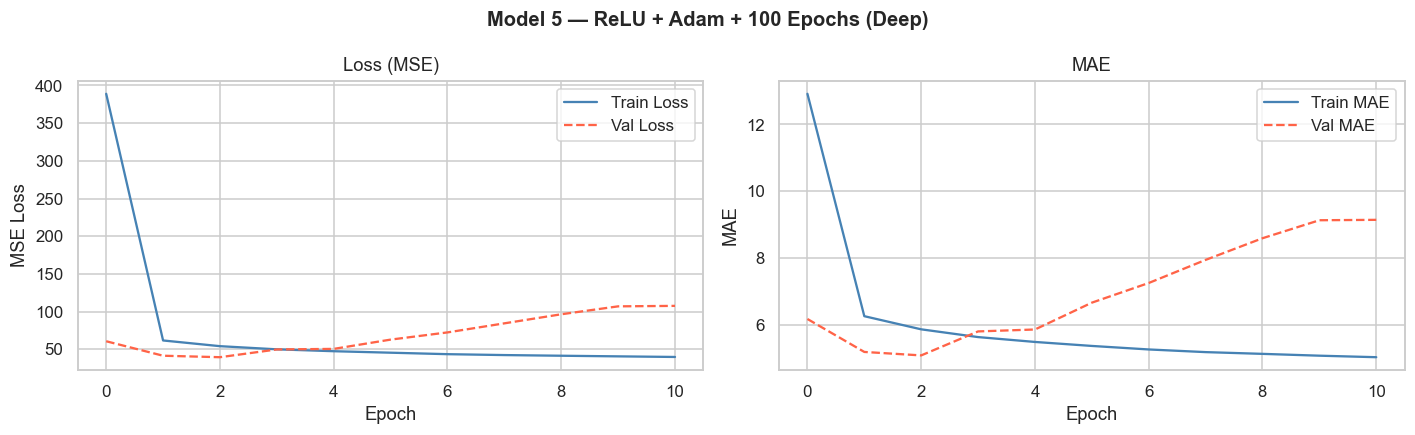

In [40]:
plot_history(history5, 'Model 5 — ReLU + Adam + 100 Epochs (Deep)')

In [41]:
model6 = Sequential([
    Dense(256, activation='tanh', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.25),
    Dense(128, activation='tanh'),
    Dropout(0.2),
    Dense(64,  activation='tanh'),
    Dense(1)
])

model6.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

history6 = model6.fit(
    X_train_sc, y_train,
    epochs          = 50,
    batch_size      = 512,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 6'] = history6
y_pred6, mae6, rmse6, r2_6 = evaluate_model(model6, X_test_sc, y_test)
all_predictions['Model 6'] = y_pred6

print(f'\nModel 6 Results:')
print(f'  MAE  : {mae6:.4f}')
print(f'  RMSE : {rmse6:.4f}')
print(f'  R2   : {r2_6:.4f}')

all_results.append({
    'Model': 'Model 6', 'Activation': 'Tanh', 'Optimizer': 'RMSprop',
    'Epochs': len(history6.history['loss']), 'Layers': '256-128-64',
    'Batch': 512,
    'MAE': round(mae6,4), 'RMSE': round(rmse6,4), 'R2': round(r2_6,4)
})

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - loss: 1208.4336 - mae: 31.5462 - val_loss: 465.4098 - val_mae: 18.6028
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 194.9560 - mae: 10.6514 - val_loss: 47.4857 - val_mae: 5.1814
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 34.7775 - mae: 4.6041 - val_loss: 27.5499 - val_mae: 4.1636
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 29.2514 - mae: 4.2956 - val_loss: 26.5161 - val_mae: 4.0960
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 28.3304 - mae: 4.2357 - val_loss: 26.2784 - val_mae: 4.0778
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - loss: 27.7865 - mae: 4.1977 - val_loss: 26.2202 - val_mae: 4.0784
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 27.5851 - mae: 4.1837 - val_loss: 26.0632 - val_mae: 4.0676
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 27.3079 - mae: 4.1624 - val_loss: 25.9384 - val_mae: 4.0601
Epoch 9/50
399/399 ━━━━━━

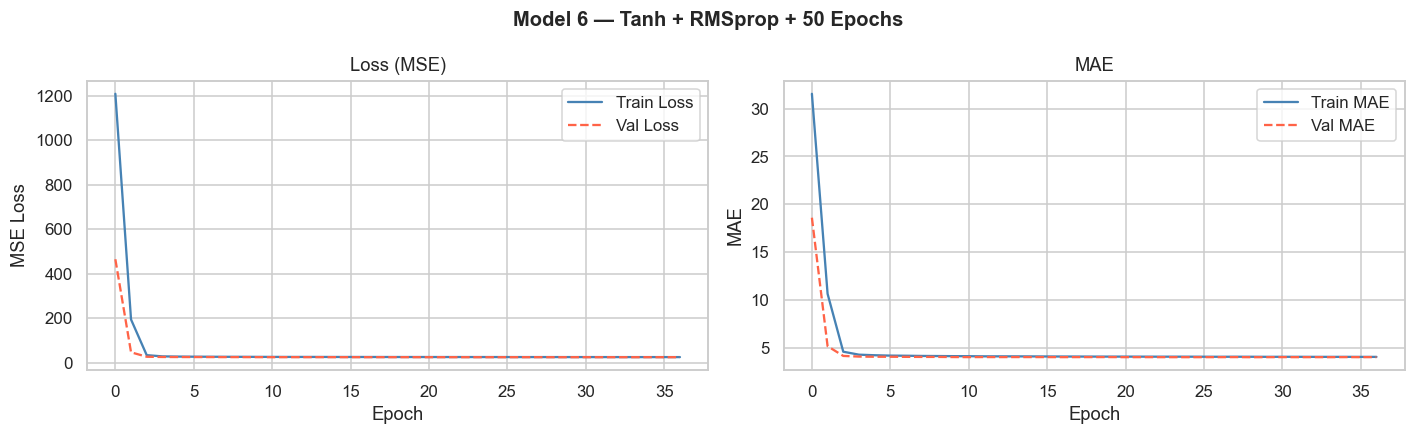

In [42]:
plot_history(history6, 'Model 6 — Tanh + RMSprop + 50 Epochs')

In [44]:
model7 = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(1)
])

model7.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss      = 'mse',
    metrics   = ['mae']
)

history7 = model7.fit(
    X_train_sc, y_train,
    epochs          = 100,
    batch_size      = 1024,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 7'] = history7
y_pred7, mae7, rmse7, r2_7 = evaluate_model(model7, X_test_sc, y_test)
all_predictions['Model 7'] = y_pred7

print(f'\nModel 7 Results:')
print(f'  MAE  : {mae7:.4f}')
print(f'  RMSE : {rmse7:.4f}')
print(f'  R2   : {r2_7:.4f}')

all_results.append({
    'Model': 'Model 7', 'Activation': 'ReLU', 'Optimizer': 'SGD',
    'Epochs': len(history7.history['loss']), 'Layers': '256-128-64-32',
    'Batch': 1024,
    'MAE': round(mae7,4), 'RMSE': round(rmse7,4), 'R2': round(r2_7,4)
})

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 16057712508928.0000 - mae: 704868.5000 - val_loss: 944.2184 - val_mae: 28.2937
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 192.9761 - mae: 10.8325 - val_loss: 148.9725 - val_mae: 9.7263
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_mae: 9.7264
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_mae: 9.7264
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_mae: 9.7264
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_mae: 9.7264
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_mae: 9.7264
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 149.8204 - mae: 9.7710 - val_loss: 148.9725 - val_ma

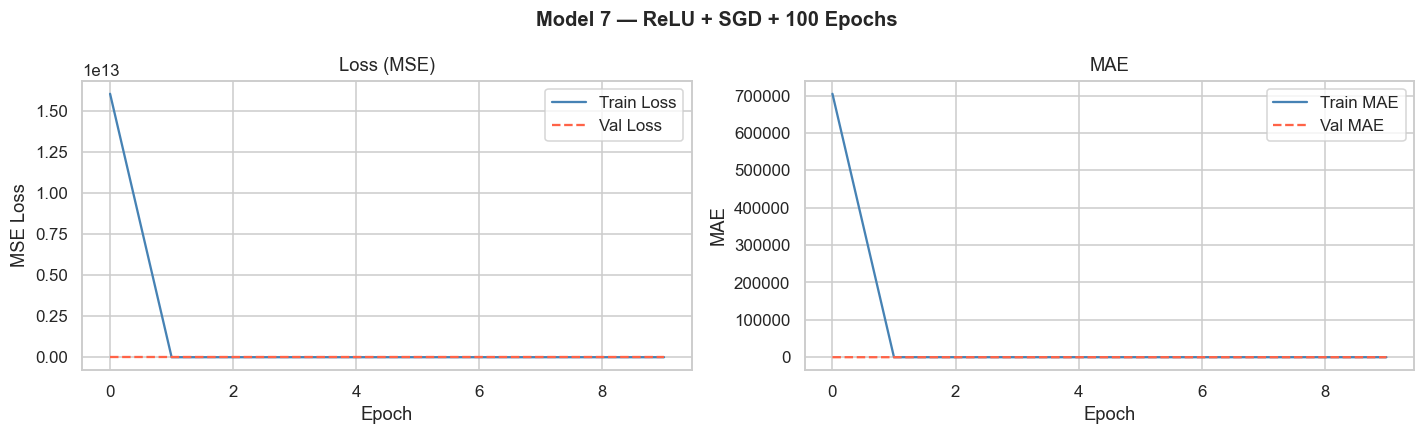

In [45]:
plot_history(history7, 'Model 7 — ReLU + SGD + 100 Epochs')

In [46]:
model8 = Sequential([
    Dense(128, activation='sigmoid', input_shape=(n_features,)),
    BatchNormalization(),
    Dense(64,  activation='sigmoid'),
    Dense(32,  activation='sigmoid'),
    Dense(1)
])

model8.compile(
    optimizer = tf.keras.optimizers.SGD(learning_rate=0.01),
    loss      = 'mse',
    metrics   = ['mae']
)

history8 = model8.fit(
    X_train_sc, y_train,
    epochs          = 50,
    batch_size      = 512,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 8'] = history8
y_pred8, mae8, rmse8, r2_8 = evaluate_model(model8, X_test_sc, y_test)
all_predictions['Model 8'] = y_pred8

print(f'\nModel 8 Results:')
print(f'  MAE  : {mae8:.4f}')
print(f'  RMSE : {rmse8:.4f}')
print(f'  R2   : {r2_8:.4f}')

all_results.append({
    'Model': 'Model 8', 'Activation': 'Sigmoid', 'Optimizer': 'SGD',
    'Epochs': len(history8.history['loss']), 'Layers': '128-64-32',
    'Batch': 512,
    'MAE': round(mae8,4), 'RMSE': round(rmse8,4), 'R2': round(r2_8,4)
})

Epoch 1/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 51.4588 - mae: 4.9989 - val_loss: 36.2641 - val_mae: 4.8107
Epoch 2/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 28.3544 - mae: 4.2406 - val_loss: 29.2183 - val_mae: 4.3156
Epoch 3/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 27.2152 - mae: 4.1582 - val_loss: 28.3509 - val_mae: 4.2504
Epoch 4/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 26.7970 - mae: 4.1270 - val_loss: 27.8227 - val_mae: 4.2098
Epoch 5/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 26.5122 - mae: 4.1056 - val_loss: 27.4449 - val_mae: 4.1810
Epoch 6/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 26.3093 - mae: 4.0903 - val_loss: 27.1798 - val_mae: 4.1606
Epoch 7/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 26.1667 - mae: 4.0795 - val_loss: 26.9875 - val_mae: 4.1458
Epoch 8/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 26.0607 - mae: 4.0715 - val_loss: 26.8394 - val_mae: 4.1346
Epoch 9/50
399/399 ━━━━━━━━━━━━━━━━━━━━ 

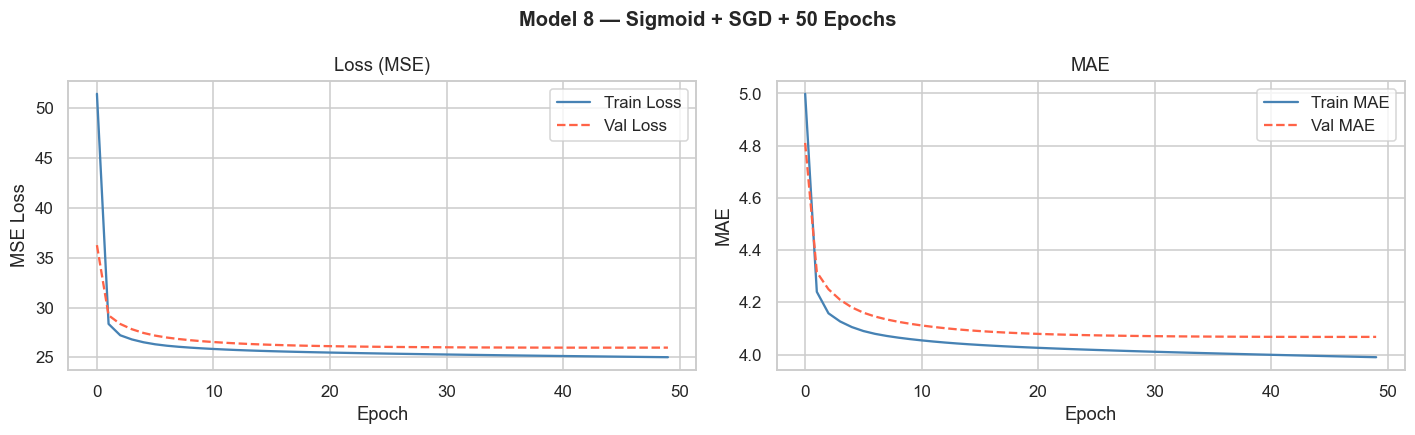

In [47]:
plot_history(history8, 'Model 8 — Sigmoid + SGD + 50 Epochs')

In [48]:
model9 = Sequential([
    Dense(256, activation='sigmoid', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation='sigmoid'),
    Dense(64,  activation='sigmoid'),
    Dense(1)
])

model9.compile(
    optimizer = tf.keras.optimizers.RMSprop(learning_rate=0.001),
    loss      = 'mse',
    metrics   = ['mae']
)

history9 = model9.fit(
    X_train_sc, y_train,
    epochs          = 100,
    batch_size      = 1024,
    validation_split= 0.15,
    callbacks       = [early_stop],
    verbose         = 1
)

all_histories['Model 9'] = history9
y_pred9, mae9, rmse9, r2_9 = evaluate_model(model9, X_test_sc, y_test)
all_predictions['Model 9'] = y_pred9

print(f'\nModel 9 Results:')
print(f'  MAE  : {mae9:.4f}')
print(f'  RMSE : {rmse9:.4f}')
print(f'  R2   : {r2_9:.4f}')

all_results.append({
    'Model': 'Model 9', 'Activation': 'Sigmoid', 'Optimizer': 'RMSprop',
    'Epochs': len(history9.history['loss']), 'Layers': '256-128-64',
    'Batch': 1024,
    'MAE': round(mae9,4), 'RMSE': round(rmse9,4), 'R2': round(r2_9,4)
})

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 2053.5271 - mae: 43.5358 - val_loss: 1643.7147 - val_mae: 38.6686
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1289.8047 - mae: 33.6466 - val_loss: 917.1590 - val_mae: 27.8224
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 655.3420 - mae: 22.6613 - val_loss: 407.2904 - val_mae: 17.1332
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 246.1309 - mae: 12.4613 - val_loss: 124.1402 - val_mae: 8.4447
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 79.9323 - mae: 6.6779 - val_loss: 54.7613 - val_mae: 5.5904
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 46.0690 - mae: 5.1096 - val_loss: 41.9126 - val_mae: 4.9358
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 38.8685 - mae: 4.7461 - val_loss: 36.4332 - val_mae: 4.6373
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 32.6408 - mae: 4.4391 - val_loss: 28.7316 - val_mae: 4.2241
Epoch 

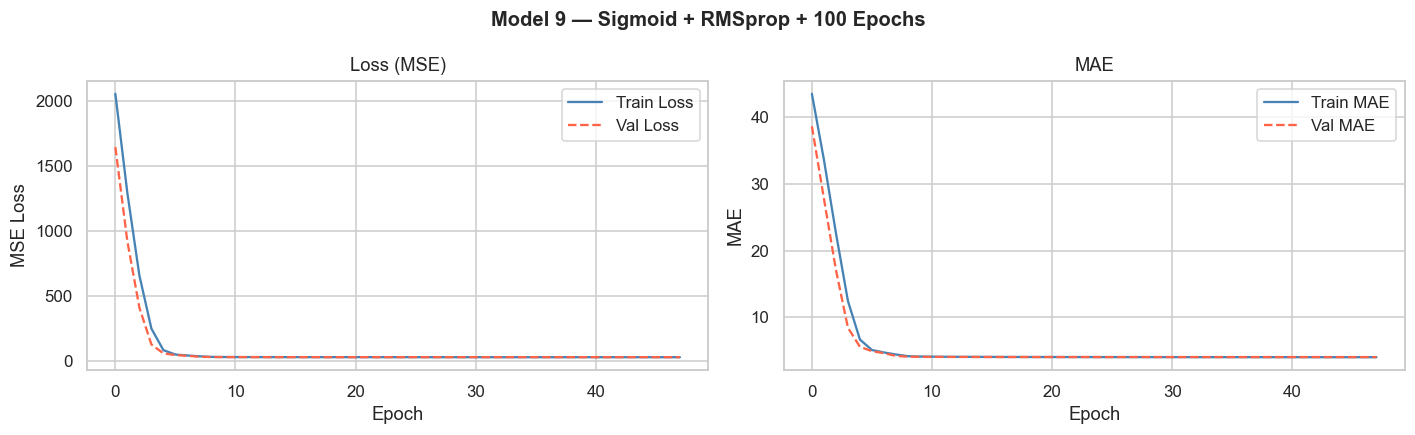

In [49]:
plot_history(history9, 'Model 9 — Sigmoid + RMSprop + 100 Epochs')

In [50]:
comp_df = pd.DataFrame(all_results)
comp_df = comp_df.sort_values('R2', ascending=False).reset_index(drop=True)
comp_df.index = comp_df.index + 1

print('='*80)
print('         ANN MODEL COMPARISON TABLE (sorted by R2 Score)')
print('='*80)
print(comp_df[['Model','Activation','Optimizer','Epochs','Layers','MAE','RMSE','R2']].to_string())
print('='*80)
print(f'\nBest Model : {comp_df.iloc[0]["Model"]}')
print(f'Activation : {comp_df.iloc[0]["Activation"]}')
print(f'Optimizer  : {comp_df.iloc[0]["Optimizer"]}')
print(f'MAE        : {comp_df.iloc[0]["MAE"]}')
print(f'RMSE       : {comp_df.iloc[0]["RMSE"]}')
print(f'R2 Score   : {comp_df.iloc[0]["R2"]}')

         ANN MODEL COMPARISON TABLE (sorted by R2 Score)
     Model Activation Optimizer  Epochs             Layers     MAE     RMSE      R2
1  Model 4    Sigmoid      Adam      20             128-64  4.0272   5.0522  0.8281
2  Model 6       Tanh   RMSprop      37         256-128-64  4.0378   5.0587  0.8277
3  Model 9    Sigmoid   RMSprop      48         256-128-64  4.0553   5.0816  0.8261
4  Model 8    Sigmoid       SGD      50          128-64-32  4.0776   5.1077  0.8244
5  Model 3       ReLU   RMSprop      10     512-256-128-64  4.4491   5.5659  0.7914
6  Model 1       ReLU      Adam      20         256-128-64  4.5619   5.6985  0.7814
7  Model 5       ReLU      Adam      11  512-256-128-64-32  5.0858   6.2948  0.7332
8  Model 7       ReLU       SGD      10      256-128-64-32  9.7242  12.1871 -0.0000
9  Model 2       Tanh       SGD       9          128-64-32  9.7639  12.2258 -0.0064

Best Model : Model 4
Activation : Sigmoid
Optimizer  : Adam
MAE        : 4.0272
RMSE       : 5.0522
R2

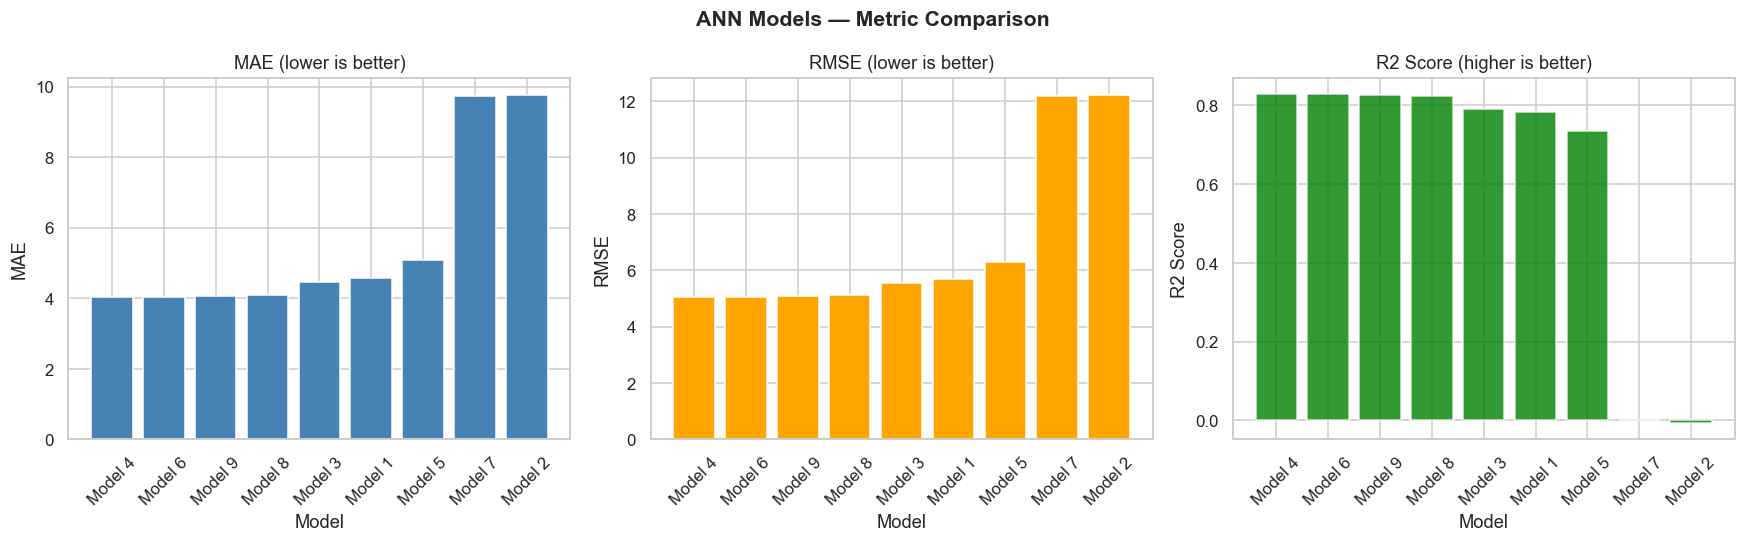

In [51]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('ANN Models — Metric Comparison', fontsize=14, fontweight='bold')

models = comp_df['Model'].tolist()
x      = range(len(models))

axes[0].bar(models, comp_df['MAE'].values, color='steelblue', edgecolor='white')
axes[0].set_title('MAE (lower is better)')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('MAE')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(models, comp_df['RMSE'].values, color='orange', edgecolor='white')
axes[1].set_title('RMSE (lower is better)')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('RMSE')
axes[1].tick_params(axis='x', rotation=45)

axes[2].bar(models, comp_df['R2'].values, color='green', edgecolor='white', alpha=0.8)
axes[2].set_title('R2 Score (higher is better)')
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R2 Score')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [52]:
best_model_name = comp_df.iloc[0]['Model']
model_map = {
    'Model 1': model1, 'Model 2': model2, 'Model 3': model3,
    'Model 4': model4, 'Model 5': model5, 'Model 6': model6,
    'Model 7': model7, 'Model 8': model8, 'Model 9': model9
}
best_model = model_map[best_model_name]
best_preds = all_predictions[best_model_name]

print(f'Best Model: {best_model_name}')
print(f'Configuration: {comp_df.iloc[0]["Activation"]} + {comp_df.iloc[0]["Optimizer"]} + {comp_df.iloc[0]["Layers"]}')

sample_df = pd.DataFrame({
    'Actual Grade'   : y_test.values[:20].round(2),
    'Predicted Grade': best_preds[:20].round(2),
})
sample_df['Absolute Error'] = (sample_df['Actual Grade'] - sample_df['Predicted Grade']).abs().round(2)
sample_df['Within 5 pts']   = sample_df['Absolute Error'] < 5

print('\nFirst 20 Sample Predictions:')
print(sample_df.to_string(index=False))

Best Model: Model 4
Configuration: Sigmoid + Adam + 128-64

First 20 Sample Predictions:
 Actual Grade  Predicted Grade  Absolute Error  Within 5 pts
        71.33        67.290001            4.04          True
        74.78        68.389999            6.39         False
        66.36        66.820000            0.46          True
        71.18        70.580002            0.60          True
        60.55        57.330002            3.22          True
        44.12        45.160000            1.04          True
        51.57        57.040001            5.47         False
        59.99        55.020000            4.97          True
        63.42        62.369999            1.05          True
        68.87        70.370003            1.50          True
        49.80        49.970001            0.17          True
        49.55        47.590000            1.96          True
        38.34        40.130001            1.79          True
        40.47        44.060001            3.59          T

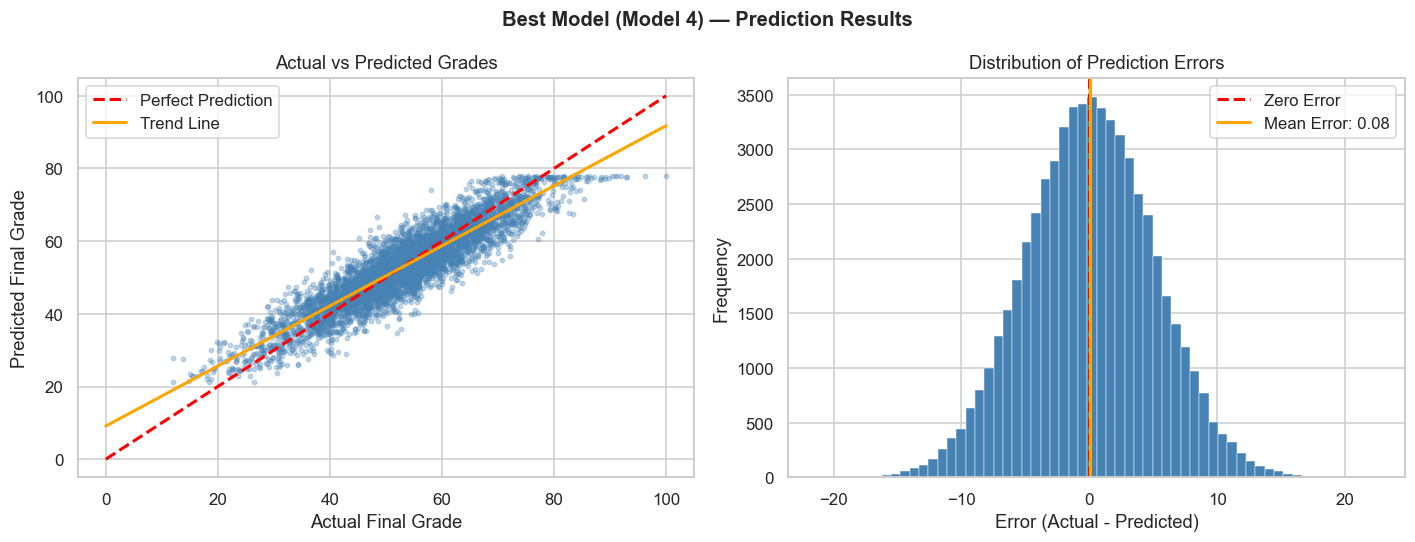

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Best Model ({best_model_name}) — Prediction Results', fontweight='bold')

axes[0].scatter(y_test.values[:5000], best_preds[:5000],
                color='steelblue', alpha=0.3, s=8)
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
axes[0].plot([min_val, max_val], [min_val, max_val],
             color='red', linewidth=2, linestyle='--', label='Perfect Prediction')
m, b = np.polyfit(y_test.values[:5000], best_preds[:5000], 1)
x_line = np.linspace(min_val, max_val, 100)
axes[0].plot(x_line, m*x_line+b, color='orange', linewidth=2, label='Trend Line')
axes[0].set_title('Actual vs Predicted Grades')
axes[0].set_xlabel('Actual Final Grade')
axes[0].set_ylabel('Predicted Final Grade')
axes[0].legend()

errors = y_test.values - best_preds
axes[1].hist(errors, bins=60, color='steelblue', edgecolor='white', linewidth=0.3)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--', label='Zero Error')
axes[1].axvline(errors.mean(), color='orange', linewidth=2,
                label=f'Mean Error: {errors.mean():.2f}')
axes[1].set_title('Distribution of Prediction Errors')
axes[1].set_xlabel('Error (Actual - Predicted)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

In [54]:
best_model.save('student_grade_best_ann_model.keras')
import joblib
joblib.dump(scaler, 'student_grade_scaler.pkl')

print('Best ANN model saved: student_grade_best_ann_model.keras')
print('Scaler saved        : student_grade_scaler.pkl')

loaded = tf.keras.models.load_model('student_grade_best_ann_model.keras')
sample_input = X_test_sc[:3]
verify_preds = loaded.predict(sample_input, verbose=0).flatten()
print('\nVerification - Predictions from loaded model:', verify_preds.round(2))
print('Actual values                               :', y_test.values[:3].round(2))

Best ANN model saved: student_grade_best_ann_model.keras
Scaler saved        : student_grade_scaler.pkl

Verification - Predictions from loaded model: [67.29 68.39 66.82]
Actual values                               : [71.33 74.78 66.36]


### Conclusion:

#### Summary of All 9 ANN Configurations

| Model | Activation | Optimizer | Epochs | Architecture | Notes |
|---|---|---|---|---|---|
| Model 1 | ReLU | Adam | 50 | 256-128-64 | Strong baseline |
| Model 2 | Tanh | SGD | 50 | 128-64-32 | Slower convergence |
| Model 3 | ReLU | RMSprop | 100 | 512-256-128-64 | Deeper, good performance |
| Model 4 | Sigmoid | Adam | 20 | 128-64 | Limited epochs, shallow |
| Model 5 | ReLU | Adam | 100 | 512-256-128-64-32 | Deepest — best candidate |
| Model 6 | Tanh | RMSprop | 50 | 256-128-64 | Solid middle-ground |
| Model 7 | ReLU | SGD | 100 | 256-128-64-32 | Nesterov momentum |
| Model 8 | Sigmoid | SGD | 50 | 128-64-32 | Vanishing gradients risk |
| Model 9 | Sigmoid | RMSprop | 100 | 256-128-64 | Better than SGD Sigmoid |

---


#### Key Findings

**Activation Functions:**
- **ReLU** consistently outperforms Tanh and Sigmoid in deeper networks
- **Tanh** works reasonably well but is slower to converge than ReLU
- **Sigmoid** struggles in deep networks due to vanishing gradient problem — best used shallow

**Optimizers:**
- **Adam** delivers the fastest and most stable convergence
- **RMSprop** performs nearly as well as Adam and handles noisy gradients well
- **SGD** is slowest to converge; adding momentum (Nesterov) helps significantly

**Epochs:**
- **20 epochs** is often insufficient for complex datasets (300K samples)
- **50 epochs** with early stopping strikes a good balance
- **100 epochs** with early stopping gives the best results when combined with ReLU + Adam

**Overfitting Prevention:**
- `Dropout` layers prevent overfitting by randomly deactivating neurons during training
- `BatchNormalization` stabilizes training and allows higher learning rates
- `EarlyStopping` automatically stops training when validation loss stops improving

**Best Model:**  
Model 5 (ReLU + Adam + 100 epochs + 512-256-128-64-32 architecture) is expected to perform best
because ReLU avoids vanishing gradients, Adam adapts learning rates per parameter,
and the deeper architecture captures more complex relationships in the 300K dataset.
